In [ ]:
import re
import string
import nltk
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)  # remove urls
    text = text.translate(str.maketrans("", "", string.punctuation))
    words = text.split()
    words = [w for w in stop_words if w not in stop_words]
    return " ".join(words)

In [48]:
from sklearn.feature_extraction.text import TfidfVectorizer

X_train = pd.read_csv('X_train.csv', sep=';')
y_train = pd.read_csv('y_train.csv', sep=';')

# Fill NaN values with empty string before vectorizing
X_train["description"] = X_train["description"].fillna("")

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=5
)

X_text = tfidf.fit_transform(X_train["description"])

In [49]:
X_train["desc_length"] = X_train["description"].apply(lambda x: len(str(x)))
X_train["word_count"] = X_train["description"].apply(lambda x: len(str(x).split()))

In [50]:
def count_hashtags(text):
    return str(text).count("#")

X_train["hashtag_count"] = X_train["description"].apply(count_hashtags)

In [51]:
import emoji

def count_emojis(text):
    return sum(1 for char in str(text) if char in emoji.EMOJI_DATA)

X_train["emoji_count"] = X_train["description"].apply(count_emojis)

In [52]:
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/jacqueshong/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [53]:
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

X_train["sentiment"] = X_train["description"].apply(
    lambda x: sia.polarity_scores(str(x))["compound"]
)

Loading data...
Vectorizing text...
Training XGBoost with 5-Fold CV...
Fold 1 R2: 0.4205 | RMSE: 1.2402
Fold 2 R2: 0.4293 | RMSE: 1.2749
Fold 3 R2: 0.5065 | RMSE: 1.2200
Fold 4 R2: 0.3688 | RMSE: 1.3640
Fold 5 R2: 0.3856 | RMSE: 1.2870

Final Mean R2: 0.4221
Final Mean RMSE: 1.2772


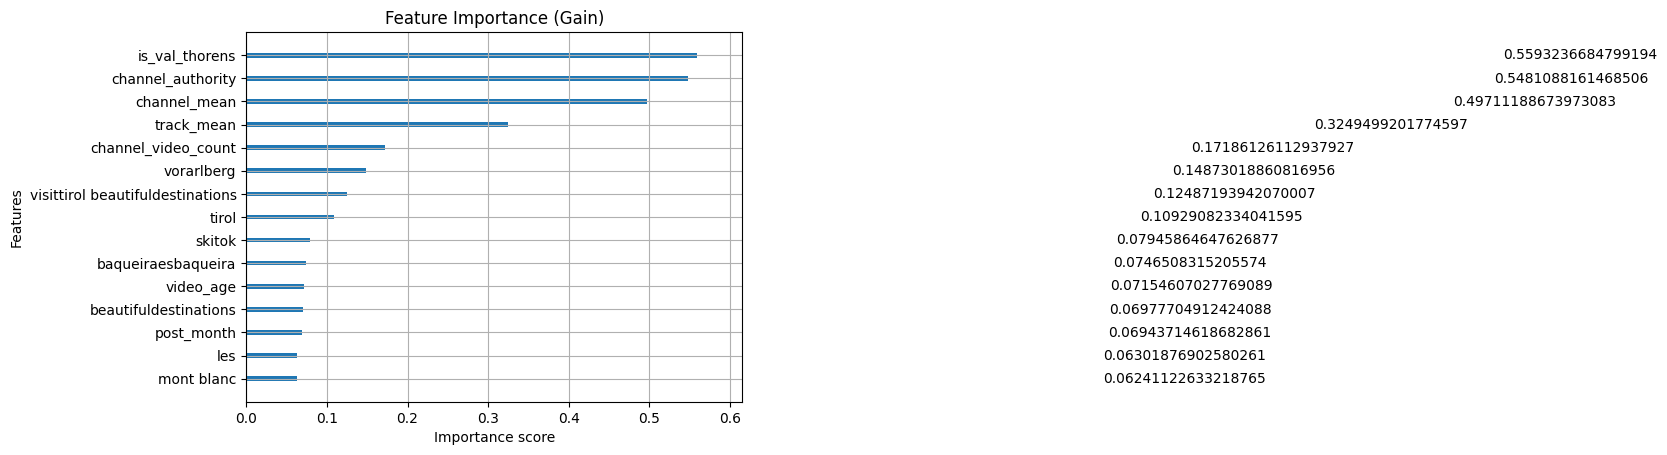

In [56]:
import pandas as pd
import numpy as np
import xgboost as xgb
import re
import ast
import string
import emoji
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Initialize Sentiment
analyzer = SentimentIntensityAnalyzer()

def engineer_features(df):
    # 1. Cleaning & Basic Text Features
    df['description'] = df['description'].fillna('')
    df['desc_len'] = df['description'].apply(len)
    df['word_count'] = df['description'].apply(lambda x: len(str(x).split()))
    df['hashtag_count'] = df['description'].apply(lambda x: len(re.findall(r'#\w+', x)))
    df['mention_count'] = df['description'].apply(lambda x: len(re.findall(r'@\w+', x)))
    
    # Emoji Count (from your notebook)
    df['emoji_count'] = df['description'].apply(lambda x: sum(1 for char in str(x) if char in emoji.EMOJI_DATA))

    # 2. VADER Sentiment Analysis with Ski Slang
    ski_slang_map = {
        "sick": "amazing", "gnarly": "impressive", "insane": "incredible",
        "crushing": "performing well", "send it": "go for it", "fail": "funny mistake"
    }
    
    def get_sentiment(text):
        text = text.lower()
        for word, replacement in ski_slang_map.items():
            text = text.replace(word, replacement)
        return analyzer.polarity_scores(text)

    sent_scores = df['description'].apply(get_sentiment)
    sent_df = pd.DataFrame(list(sent_scores))
    df['sent_compound'] = sent_df['compound'].values

    # 3. Temporal Features (Target year 2026)
    df['video_age'] = 2026 - df['release_year'].fillna(df['release_year'].median())
    # Extract timestamp from ID if applicable
    df['post_date'] = df['id'].astype(int).apply(lambda x: pd.Timestamp((int(x) >> 32), unit='s'))
    df['post_month'] = df['post_date'].dt.month

    # 4. Metadata & Frequency
    df['artist_count'] = df['artists'].apply(lambda x: len(ast.literal_eval(x)) if pd.notna(x) and str(x).startswith('[') else 1)
    df['channel_video_count'] = df.groupby('channel')['id'].transform('count')

    # 5. Viral Pattern Features
    df['is_optimal_duration'] = df['video_duration'].between(6, 12).astype(int)
    df['is_minimalist'] = (df['desc_len'] <= 20).astype(int)
    df['is_val_thorens'] = (df['channel'].str.contains('Val Thorens', na=False)).astype(int)

    # Smoothed Channel Authority
    if 'popularity' in df.columns:
        alpha = 5
        global_mean = np.log1p(df['popularity']).mean()
        agg = df.groupby('channel')['popularity'].transform(lambda x: (np.log1p(x).sum() + alpha * global_mean) / (len(x) + alpha))
        df['channel_authority'] = agg
    else:
        df['channel_authority'] = 0 
    
    return df

# --- MAIN EXECUTION ---
print("Loading data...")
X_df = pd.read_csv('X_train.csv', sep=';')
y_df = pd.read_csv('y_train.csv', sep=';')
data = X_df.merge(y_df, left_on='id', right_on='ID')

data = engineer_features(data)

# --- TF-IDF Processing ---
print("Vectorizing text...")
tfidf = TfidfVectorizer(max_features=100, stop_words='english', ngram_range=(1,2))
tfidf_matrix = tfidf.fit_transform(data['description'])
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf.get_feature_names_out())

# Combine numeric features with TF-IDF features
numeric_features = [
    'desc_len', 'word_count', 'hashtag_count', 'emoji_count',
    'video_age', 'artist_count', 'video_duration',
    'channel_video_count', 'post_month', 'sent_compound', 
    'is_optimal_duration', 'is_minimalist', 'is_val_thorens', 'channel_authority'
]
categorical_cols = ['channel', 'track']

X = pd.concat([data[numeric_features + categorical_cols], tfidf_df], axis=1)
y = np.log1p(data['popularity']) 

print("Training XGBoost with 5-Fold CV...")
kf = KFold(n_splits=5, shuffle=True, random_state=42)
r2_scores = []
rmse_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    X_train_fold, X_val_fold = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
    y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]

    # Target Encoding for categorical variables
    for col in categorical_cols:
        mean_enc = y_train_fold.groupby(X_train_fold[col]).mean()
        X_train_fold[f'{col}_mean'] = X_train_fold[col].map(mean_enc).fillna(y_train_fold.mean())
        X_val_fold[f'{col}_mean'] = X_val_fold[col].map(mean_enc).fillna(y_train_fold.mean())
    
    X_train_fold = X_train_fold.drop(columns=categorical_cols)
    X_val_fold = X_val_fold.drop(columns=categorical_cols)

    model = xgb.XGBRegressor(
        n_estimators=1000, learning_rate=0.05, max_depth=5, 
        subsample=0.8, colsample_bytree=0.7, tree_method='hist',
        early_stopping_rounds=50, random_state=42
    )

    model.fit(X_train_fold, y_train_fold, eval_set=[(X_val_fold, y_val_fold)], verbose=False)

    preds = np.expm1(model.predict(X_val_fold))
    r2_scores.append(r2_score(np.expm1(y_val_fold), preds))
    rmse = np.sqrt(mean_squared_error(np.expm1(y_val_fold), preds))
    rmse_scores.append(rmse)
    print(f"Fold {fold+1} R2: {r2_scores[-1]:.4f} | RMSE: {rmse:.4f}")

print(f"\nFinal Mean R2: {np.mean(r2_scores):.4f}")
print(f"Final Mean RMSE: {np.mean(rmse_scores):.4f}")

# Plot Importance
xgb.plot_importance(model, importance_type='gain', max_num_features=15)
plt.title("Feature Importance (Gain)")
plt.show()

[I 2026-03-02 15:18:16,075] A new study created in memory with name: no-name-0ce451c3-1550-4227-b67a-9fd544fc5cb9


Running Optuna hyperparameter search (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-03-02 15:18:16,766] Trial 0 finished with value: 1.5219917386852764 and parameters: {'n_estimators': 534, 'learning_rate': 0.0150945582071978, 'max_depth': 6, 'subsample': 0.7736805947674956, 'colsample_bytree': 0.6762270292195534, 'min_child_weight': 4, 'gamma': 3.516193506075153, 'reg_alpha': 7.362124784767649e-07, 'reg_lambda': 0.00010309033990438183}. Best is trial 0 with value: 1.5219917386852764.
[I 2026-03-02 15:18:17,239] Trial 1 finished with value: 1.5284729117119618 and parameters: {'n_estimators': 321, 'learning_rate': 0.11161234714668697, 'max_depth': 8, 'subsample': 0.60651558227996, 'colsample_bytree': 0.7387290555033854, 'min_child_weight': 1, 'gamma': 3.5614343502005124, 'reg_alpha': 5.476654119209797e-07, 'reg_lambda': 0.005319604899751489}. Best is trial 0 with value: 1.5219917386852764.
[I 2026-03-02 15:18:18,118] Trial 2 finished with value: 1.461789133376777 and parameters: {'n_estimators': 1171, 'learning_rate': 0.019603559745451794, 'max_depth': 6, 'subs

/var/folders/j1/d32ct0l12lb578lj_3txypf00000gn/T/ipykernel_1964/3821294632.py:86: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study)


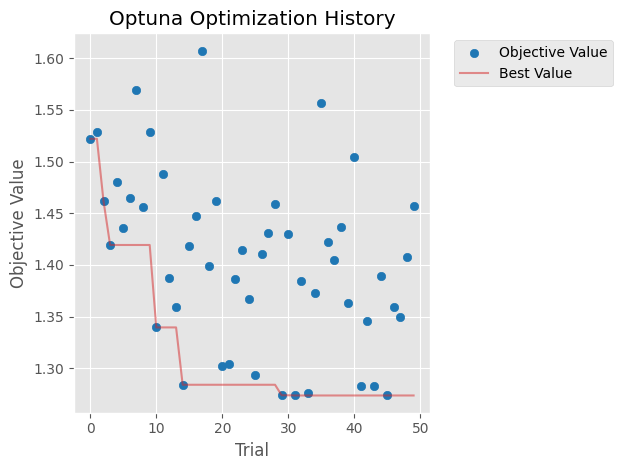

/var/folders/j1/d32ct0l12lb578lj_3txypf00000gn/T/ipykernel_1964/3821294632.py:90: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_param_importances(study)


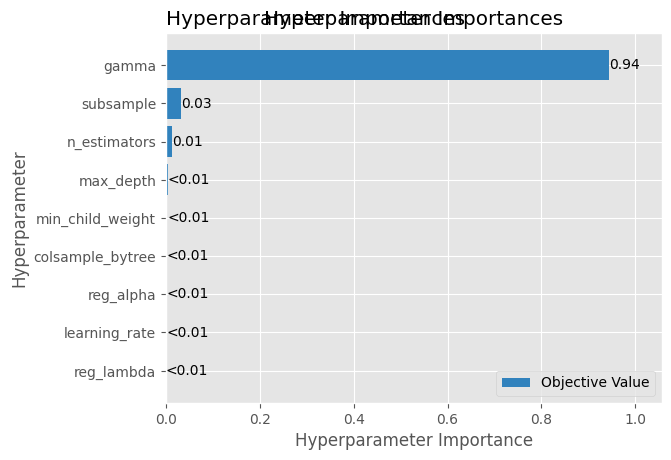

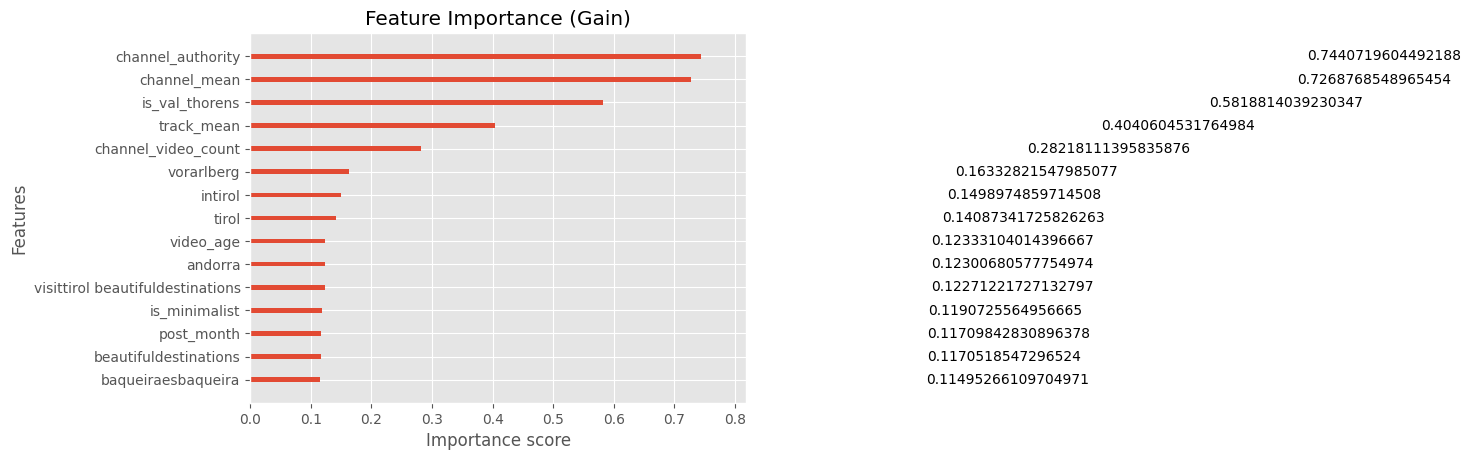

In [58]:
import optuna

# --- OPTUNA OBJECTIVE ---
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'tree_method': 'hist',
        'random_state': 42
    }

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    rmse_scores = []

    for train_idx, val_idx in kf.split(X):
        X_train_fold, X_val_fold = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
        y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]

        for col in categorical_cols:
            mean_enc = y_train_fold.groupby(X_train_fold[col]).mean()
            X_train_fold[f'{col}_mean'] = X_train_fold[col].map(mean_enc).fillna(y_train_fold.mean())
            X_val_fold[f'{col}_mean'] = X_val_fold[col].map(mean_enc).fillna(y_train_fold.mean())

        X_train_fold = X_train_fold.drop(columns=categorical_cols)
        X_val_fold = X_val_fold.drop(columns=categorical_cols)

        model = xgb.XGBRegressor(**params, early_stopping_rounds=50)
        model.fit(X_train_fold, y_train_fold, eval_set=[(X_val_fold, y_val_fold)], verbose=False)

        preds = np.expm1(model.predict(X_val_fold))
        rmse = np.sqrt(mean_squared_error(np.expm1(y_val_fold), preds))
        rmse_scores.append(rmse)

    return np.mean(rmse_scores)

# --- RUN OPTUNA ---
print("Running Optuna hyperparameter search (50 trials)...")
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nBest RMSE: {study.best_value:.4f}")
print(f"Best Params: {study.best_params}")

# --- TRAIN FINAL MODEL WITH BEST PARAMS ---
print("\nTraining final model with best parameters...")
best_params = study.best_params
best_params['tree_method'] = 'hist'
best_params['random_state'] = 42

kf = KFold(n_splits=5, shuffle=True, random_state=42)
r2_scores = []
rmse_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    X_train_fold, X_val_fold = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
    y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]

    for col in categorical_cols:
        mean_enc = y_train_fold.groupby(X_train_fold[col]).mean()
        X_train_fold[f'{col}_mean'] = X_train_fold[col].map(mean_enc).fillna(y_train_fold.mean())
        X_val_fold[f'{col}_mean'] = X_val_fold[col].map(mean_enc).fillna(y_train_fold.mean())

    X_train_fold = X_train_fold.drop(columns=categorical_cols)
    X_val_fold = X_val_fold.drop(columns=categorical_cols)

    model = xgb.XGBRegressor(**best_params, early_stopping_rounds=50)
    model.fit(X_train_fold, y_train_fold, eval_set=[(X_val_fold, y_val_fold)], verbose=False)

    preds = np.expm1(model.predict(X_val_fold))
    r2_scores.append(r2_score(np.expm1(y_val_fold), preds))
    rmse = np.sqrt(mean_squared_error(np.expm1(y_val_fold), preds))
    rmse_scores.append(rmse)
    print(f"Fold {fold+1} R2: {r2_scores[-1]:.4f} | RMSE: {rmse:.4f}")

print(f"\nFinal Mean R2: {np.mean(r2_scores):.4f}")
print(f"Final Mean RMSE: {np.mean(rmse_scores):.4f}")

# --- OPTUNA VISUALIZATION ---
optuna.visualization.matplotlib.plot_optimization_history(study)
plt.title("Optuna Optimization History")
plt.show()

optuna.visualization.matplotlib.plot_param_importances(study)
plt.title("Hyperparameter Importances")
plt.show()

# --- FEATURE IMPORTANCE ---
xgb.plot_importance(model, importance_type='gain', max_num_features=15)
plt.title("Feature Importance (Gain)")
plt.show()

In [62]:
# --- GENERATE SUBMISSION FROM TEXT MODEL ---
print("Loading and processing test data...")
X_test_raw = pd.read_csv('X_test.csv', sep=';')
test_ids = X_test_raw['id'].copy()

X_test_raw = engineer_features(X_test_raw)

# Apply channel authority from training data
channel_authority_map = data.groupby('channel')['channel_authority'].mean()
X_test_raw['channel_authority'] = X_test_raw['channel'].map(channel_authority_map).fillna(0)

# TF-IDF transform (using already fitted tfidf)
tfidf_test = pd.DataFrame(
    tfidf.transform(X_test_raw['description']).toarray(),
    columns=tfidf.get_feature_names_out()
)

X_test_final = pd.concat([
    X_test_raw[numeric_features + categorical_cols].reset_index(drop=True),
    tfidf_test
], axis=1)

# Target encoding using full training data encodings
channel_mean_enc = y.groupby(X['channel']).mean()
track_mean_enc = y.groupby(X['track']).mean()

X_test_final['channel_mean'] = X_test_final['channel'].map(channel_mean_enc).fillna(y.mean())
X_test_final['track_mean'] = X_test_final['track'].map(track_mean_enc).fillna(y.mean())
X_test_final = X_test_final.drop(columns=categorical_cols)

# Train final model on ALL training data with best params
print("Training final model on full training data...")
X_full = X.copy()
X_full['channel_mean'] = X_full['channel'].map(channel_mean_enc).fillna(y.mean())
X_full['track_mean'] = X_full['track'].map(track_mean_enc).fillna(y.mean())
X_full = X_full.drop(columns=categorical_cols)

final_model = xgb.XGBRegressor(**best_params)
final_model.fit(X_full, y, verbose=False)

# Predict & save
predictions = np.expm1(final_model.predict(X_test_final))
predictions = np.clip(predictions, 0, None)  # no negative popularity

submission = pd.DataFrame({
    'ID': test_ids.values,
    'popularity': predictions
})

submission.to_csv('submission_text.csv', index=False, sep=',')
print(f"submission_text.csv saved — {len(submission)} rows")
print(submission.head())
print(submission['popularity'].describe())

Loading and processing test data...
Training final model on full training data...
submission_text.csv saved — 338 rows
                    ID  popularity
0  7568823330518748438    8.730117
1  7546523294489414934    8.830746
2  7504292781637127446    7.903373
3  7462655968522931478    8.504113
4  7442737337525669142    8.849721
count    338.000000
mean       7.629581
std        0.955240
min        5.117520
25%        6.983521
50%        7.478589
75%        8.139173
max       10.643340
Name: popularity, dtype: float64
